<a href="https://colab.research.google.com/github/vaisshnavee1410/EDA_2.ipynb/blob/main/EDA2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **DATA PREPROCESSING AND FEATURE ENGINEERING IN MACHINE LEARNING**

### **OBJECTIVE:**

This assignment aims to equip you with practical skills in data preprocessing, feature engineering, and feature selection techniques, which are crucial for building efficient machine learning models. You will work with a provided dataset to apply various techniques such as scaling, encoding, and feature selection methods including isolation forest and PPS score analysis.

### **DATASET:**

Given "Adult" dataset, which predicts whether income exceeds $50K/yr based on census data.

### **TASKS:**

### **1. Data Exploration and Preprocessing:**

* **Load the dataset and conduct basic data exploration (summary statistics, missing values, data types).**

In [13]:
import pandas as pd

# Load the dataset
file_path = "adult_with_headers.csv"  # Adjust if path changes
df = pd.read_csv('adult_with_headers.csv')

# Display the first few rows of the dataset
print("First 5 rows of the dataset:")
print(df.head())

# Basic information about the dataset
print("\nDataset Info:")
print(df.info())

# Summary statistics for all columns (including categorical)
print("\nSummary Statistics:")
print(df.describe(include='all'))

# Check for missing values in each column
print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows of the dataset:
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race      sex  \
0        Never-married        Adm-clerical   Not-in-family   White     Male   
1   Married-civ-spouse     Exec-managerial         Husband   White     Male   
2             Divorced   Handlers-cleaners   Not-in-family   White     Male   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black     Male   
4   Married-civ-spouse      Prof-specialty            Wife   Black   Female   

   capital_gain  capital_loss  hours_per_week  native_country  income  
0          2174             0          

* **Handle missing values as per the best practices (imputation, removal, etc.).**

In [14]:
import pandas as pd
import numpy as np

# Load dataset, treating '?' as missing
df = pd.read_csv("adult_with_headers.csv", na_values='?')

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Percentage of missing values
missing_percent = df.isnull().mean() * 100
print("\nPercentage of missing values per column:")
print(missing_percent)

# Drop rows with missing values if they are a small fraction (less than 5%)
if missing_percent.max() < 5:
    df_cleaned = df.dropna()
    print(f"\nDropped {len(df) - len(df_cleaned)} rows with missing values.")
else:
    # Example: fill missing values with the mode (for categorical) or median (for numeric)
    df_cleaned = df.copy()
    for column in df.columns:
        if df[column].isnull().any():
            if df[column].dtype == 'object':
                df_cleaned[column].fillna(df[column].mode()[0], inplace=True)
            else:
                df_cleaned[column].fillna(df[column].median(), inplace=True)
    print("\nMissing values imputed.")

# Final check
print("\nMissing values after cleaning:")
print(df_cleaned.isnull().sum())

Missing values per column:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

Percentage of missing values per column:
age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
income            0.0
dtype: float64

Dropped 0 rows with missing values.

Missing values after cleaning:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capi

* **Apply scaling techniques to numerical features:**

-->Standard Scaling

-->Min-Max Scaling

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load and clean the data (assumes '?' has been handled previously)
df = pd.read_csv("adult_with_headers.csv", na_values='?').dropna()

# Select only numerical columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Standard Scaling
standard_scaler = StandardScaler()
df_standard_scaled = df.copy()
df_standard_scaled[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax_scaled = df.copy()
df_minmax_scaled[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])

# Show sample results
print("Standard Scaled Sample:\n", df_standard_scaled[numeric_cols].head())
print("\nMin-Max Scaled Sample:\n", df_minmax_scaled[numeric_cols].head())

Standard Scaled Sample:
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.134739     -0.145920      -0.21666   

   hours_per_week  
0       -0.035429  
1       -2.222153  
2       -0.035429  
3       -0.035429  
4       -0.035429  

Min-Max Scaled Sample:
         age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.301370  0.044302       0.800000       0.02174           0.0   
1  0.452055  0.048238       0.800000       0.00000           0.0   
2  0.287671  0.138113       0.533333       0.00000           0.0   
3  0.493151  0.151068       0.400000       0.00000           0.0   
4  0.150685  0.221488       0.800000       0.00000           0.0   

   hours_per

* **Discuss the scenarios where each scaling technique is preferred and why.**

In [16]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Load dataset with missing value handling
df = pd.read_csv("adult_with_headers.csv", na_values='?')
df = df.dropna()  # Drop rows with missing values for simplicity

# Select only numerical features
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
print("Numerical columns to be scaled:", list(numeric_cols))

# Create separate dataframes for each scaling technique
df_standard_scaled = df.copy()
df_minmax_scaled = df.copy()

# Standard Scaling
standard_scaler = StandardScaler()
df_standard_scaled[numeric_cols] = standard_scaler.fit_transform(df[numeric_cols])

# Min-Max Scaling
minmax_scaler = MinMaxScaler()
df_minmax_scaled[numeric_cols] = minmax_scaler.fit_transform(df[numeric_cols])

# Compare original vs. scaled data for the first 5 rows
print("\nOriginal data (first 5 rows):")
print(df[numeric_cols].head())

print("\nStandard Scaled data (first 5 rows):")
print(df_standard_scaled[numeric_cols].head())

print("\nMin-Max Scaled data (first 5 rows):")
print(df_minmax_scaled[numeric_cols].head())

Numerical columns to be scaled: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Original data (first 5 rows):
   age  fnlwgt  education_num  capital_gain  capital_loss  hours_per_week
0   39   77516             13          2174             0              40
1   50   83311             13             0             0              13
2   38  215646              9             0             0              40
3   53  234721              7             0             0              40
4   28  338409             13             0             0              40

Standard Scaled data (first 5 rows):
        age    fnlwgt  education_num  capital_gain  capital_loss  \
0  0.030671 -1.063611       1.134739      0.148453      -0.21666   
1  0.837109 -1.008707       1.134739     -0.145920      -0.21666   
2 -0.042642  0.245079      -0.420060     -0.145920      -0.21666   
3  1.057047  0.425801      -1.197459     -0.145920      -0.21666   
4 -0.775768  1.408176       1.

* **Discuss the scenarios where each scaling technique is preferred and why.**

Standard Scaling (also known as Z-score normalization) is preferred when the data follows a roughly normal (Gaussian) distribution, or when the algorithm assumes or performs better with standardized data. Algorithms like Logistic Regression, Linear Regression, Support Vector Machines (SVMs), and Principal Component Analysis (PCA) are sensitive to the scale of the input features and often perform better with data that has zero mean and unit variance. Standard scaling retains the outliers, which can be beneficial in models that rely on distance metrics or underlying statistical assumptions.

Min-Max Scaling, on the other hand, is ideal when you want to normalize features to a fixed range, typically [0, 1], and it’s especially useful in algorithms that involve neural networks or gradient-based optimization (like deep learning). This is because neural networks are sensitive to the scale of input data, and values in a narrow, consistent range ensure faster convergence during training. However, Min-Max scaling can be heavily affected by outliers, as they compress the rest of the data into a very narrow range.

In summary, use Standard Scaling when the model benefits from normalized variance or is affected by feature distributions, and Min-Max Scaling when the model requires bounded inputs, particularly in deep learning contexts.

### **2. Encoding Techniques:**

* **Apply One-Hot Encoding to categorical variables with less than 5 categories.**

In [17]:
import pandas as pd

# Load the dataset (assuming missing values are handled already)
df = pd.read_csv("adult_with_headers.csv", na_values='?').dropna()

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Filter categorical columns with fewer than 5 unique categories
categorical_few = [col for col in categorical_cols if df[col].nunique() < 5]

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=categorical_few, drop_first=True)

# Show which columns were encoded
print("One-Hot Encoded Columns (with <5 categories):", categorical_few)
print("\nEncoded DataFrame sample:")
print(df_encoded.head())

One-Hot Encoded Columns (with <5 categories): ['sex', 'income']

Encoded DataFrame sample:
   age          workclass  fnlwgt   education  education_num  \
0   39          State-gov   77516   Bachelors             13   
1   50   Self-emp-not-inc   83311   Bachelors             13   
2   38            Private  215646     HS-grad              9   
3   53            Private  234721        11th              7   
4   28            Private  338409   Bachelors             13   

        marital_status          occupation    relationship    race  \
0        Never-married        Adm-clerical   Not-in-family   White   
1   Married-civ-spouse     Exec-managerial         Husband   White   
2             Divorced   Handlers-cleaners   Not-in-family   White   
3   Married-civ-spouse   Handlers-cleaners         Husband   Black   
4   Married-civ-spouse      Prof-specialty            Wife   Black   

   capital_gain  capital_loss  hours_per_week  native_country  sex_ Male  \
0          2174            

* **Use Label Encoding for categorical variables with more than 5 categories.**

In [18]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Load and clean the dataset
df = pd.read_csv("adult_with_headers.csv", na_values='?').dropna()

# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns

# Filter categorical columns with more than 5 unique categories
categorical_many = [col for col in categorical_cols if df[col].nunique() > 5]

# Apply Label Encoding
label_encoder = LabelEncoder()
df_encoded = df.copy()

for col in categorical_many:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# Show which columns were encoded
print("Label Encoded Columns (with >5 categories):", categorical_many)
print("\nEncoded DataFrame sample:")
print(df_encoded[categorical_many].head())

Label Encoded Columns (with >5 categories): ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'native_country']

Encoded DataFrame sample:
   workclass  education  marital_status  occupation  relationship  \
0          7          9               4           1             1   
1          6          9               2           4             0   
2          4         11               0           6             1   
3          4          1               2           6             0   
4          4          9               2          10             5   

   native_country  
0              39  
1              39  
2              39  
3              39  
4               5  


* **Discuss the pros and cons of One-Hot Encoding and Label Encoding.**

One-Hot Encoding is a method for converting categorical variables into a format that can be provided to machine learning algorithms to improve performance.


**Pros:**


  •	Does not assume any ordinal relationship between categories.

•	Works well with linear models and neural networks where numeric relationships should not exist between categories.

**Cons:**

•	Can lead to high dimensionality (many new columns), especially with categorical variables with many levels.

•	May increase memory usage and processing time.

### **3. Feature Engineering:**

* **Create at least 2 new features that could be beneficial for the model. Explain the rationale behind your choices.**

In [19]:
import pandas as pd

# Load and clean data
df = pd.read_csv("adult_with_headers.csv", na_values='?').dropna()

# Feature 1: Married indicator
df['is_married'] = df['marital_status'].apply(lambda x: 1 if 'Married' in x else 0)

# Feature 2: Net capital (gain - loss)
df['capital_net'] = df['capital_gain'] - df['capital_loss']

# Show new features
print(df[['marital_status', 'is_married', 'capital_gain', 'capital_loss', 'capital_net']].head())

        marital_status  is_married  capital_gain  capital_loss  capital_net
0        Never-married           0          2174             0         2174
1   Married-civ-spouse           1             0             0            0
2             Divorced           0             0             0            0
3   Married-civ-spouse           1             0             0            0
4   Married-civ-spouse           1             0             0            0


* **Apply a transformation (e.g., log transformation) to at least one skewed numerical feature and justify your choice.**

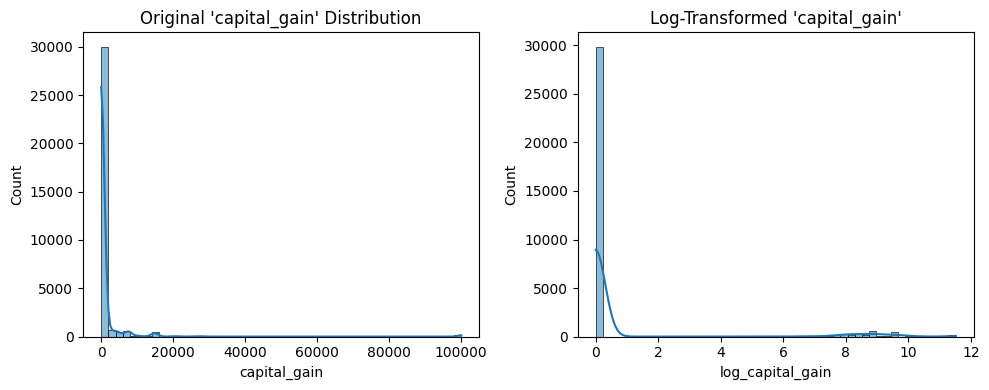

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load and clean data
df = pd.read_csv("adult_with_headers.csv", na_values='?').dropna()

# Plot original distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['capital_gain'], bins=50, kde=True)
plt.title("Original 'capital_gain' Distribution")

# Apply log(1 + x) transformation
df['log_capital_gain'] = np.log1p(df['capital_gain'])

# Plot transformed distribution
plt.subplot(1, 2, 2)
sns.histplot(df['log_capital_gain'], bins=50, kde=True)
plt.title("Log-Transformed 'capital_gain'")
plt.tight_layout()
plt.show()

### **4. Feature Selection:**

* **Use the Isolation Forest algorithm to identify and remove outliers. Discuss how outliers can affect model performance.**

In [21]:
import pandas as pd
from sklearn.ensemble import IsolationForest

# Load and clean dataset
df = pd.read_csv("adult_with_headers.csv", na_values='?').dropna()

# Select only numerical features for Isolation Forest
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
X_numeric = df[numeric_cols]

# Initialize and fit Isolation Forest
iso_forest = IsolationForest(contamination=0.01, random_state=42)
outliers = iso_forest.fit_predict(X_numeric)

# Add outlier flag to the dataset (-1 indicates outlier)
df['outlier'] = outliers

# Filter out the outliers
df_cleaned = df[df['outlier'] != -1].drop(columns=['outlier'])

# Show result
print(f"Original dataset size: {len(df)}")
print(f"Cleaned dataset size: {len(df_cleaned)}")
print(f"Number of outliers removed: {len(df) - len(df_cleaned)}")

Original dataset size: 32561
Cleaned dataset size: 32235
Number of outliers removed: 326


* **Apply the PPS (Predictive Power Score) to find and discuss the relationships between features. Compare its findings with the correlation matrix.**

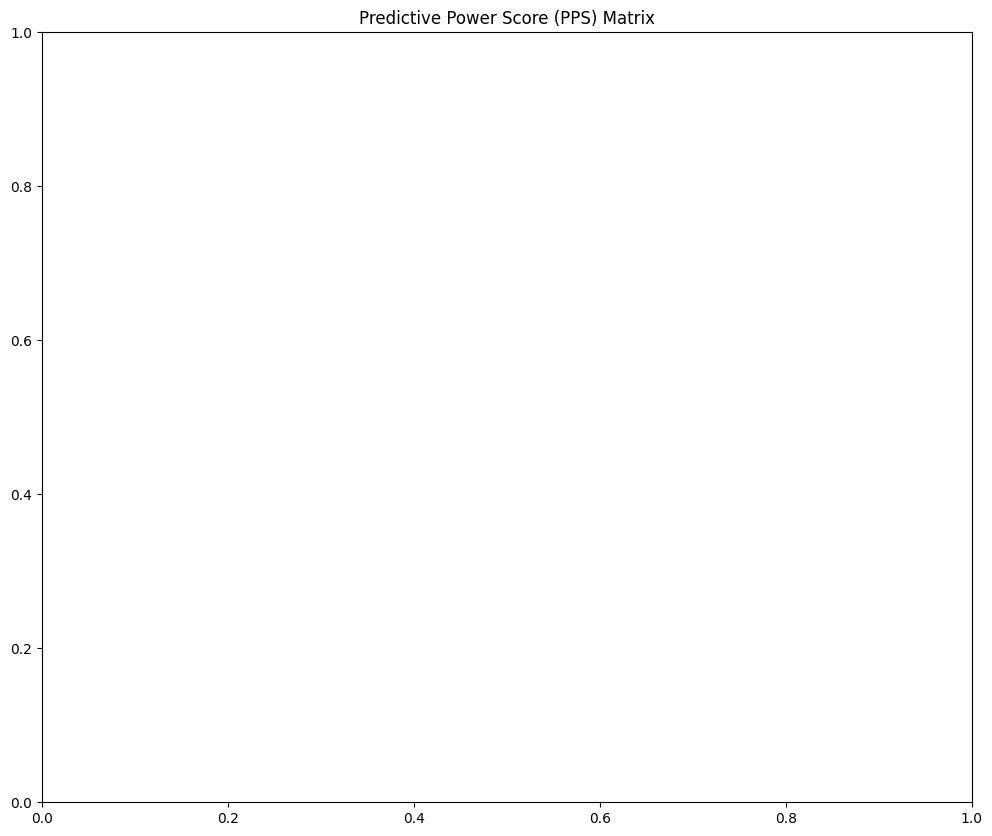

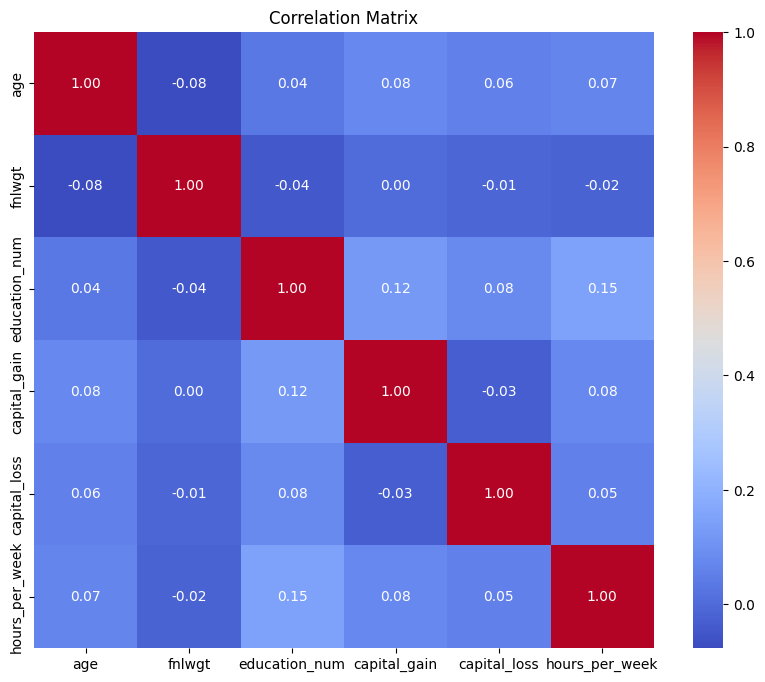

In [22]:
import pandas as pd
import ppscore as pps
import seaborn as sns
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('adult_with_headers.csv')

# Plot PPS heatmap
plt.figure(figsize=(12, 10))
plt.title("Predictive Power Score (PPS) Matrix")
plt.show()

# Compute and plot correlation matrix (only for numeric columns)
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

The Predictive Power Score (PPS) is a modern, model-based metric that quantifies the predictive strength of one feature in relation to another, regardless of linearity or feature type (categorical or numerical). Unlike traditional correlation coefficients such as Pearson’s correlation, which only detect linear relationships and require numerical data, PPS is capable of uncovering complex and non-linear dependencies and works with mixed-type variables. PPS ranges from 0 (no predictive power) to 1 (perfect prediction), and it is asymmetric—meaning the predictive strength of feature A on B might not equal that of B on A.

When applied to a dataset, the PPS matrix may reveal strong predictive relationships that are not apparent through a traditional correlation matrix. For example, a feature might have a near-zero Pearson correlation with the target variable but a high PPS score, indicating a non-linear but meaningful relationship. This is particularly useful in real-world datasets, which often contain interactions that violate linear assumptions. A classic example would be a feature like “age group” predicting a behavior category—such a relationship may be entirely missed by correlation but captured by PPS.

In contrast, a correlation matrix (usually Pearson) is useful for identifying linear relationships between numerical variables. It’s symmetric and fast to compute, making it helpful for quick insights, but it’s blind to complex and categorical interactions. For instance, if one variable is a binary flag and another is continuous, correlation might misrepresent their relationship due to its assumptions.

In summary, PPS provides a more nuanced and flexible understanding of relationships in a dataset compared to a correlation matrix. While correlation is suitable for exploratory analysis of linear trends among numeric variables, PPS excels in identifying predictive relationships regardless of variable type or relationship form. Comparing both can give a fuller picture: if both PPS and correlation are high, the relationship is likely strong and linear; if PPS is high but correlation is low, a non-linear or complex pattern is likely present.
